In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("student_performance_prediction.csv")

In [5]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [6]:
df.shape

(40000, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  object 
 5   Parent Education Level                       38000 non-null  object 
 6   Passed                                       38000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB


In [8]:
df.columns

Index(['Student ID', 'Study Hours per Week', 'Attendance Rate',
       'Previous Grades', 'Participation in Extracurricular Activities',
       'Parent Education Level', 'Passed'],
      dtype='object')

In [9]:
df.describe()

,Study Hours per Week,Attendance Rate,Previous Grades
count,38005.000000,38008.000000,38006.000000
mean,9.962744,75.276323,65.440107
std,5.031154,20.393418,16.503119
min,-12.300000,-14.300000,8.300000
25%,6.600000,61.600000,55.100000
50%,10.000000,75.300000,65.200000
75%,13.400000,88.800000,75.200000
max,32.400000,150.200000,200.000000


In [10]:
df.describe(include = 'all')

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
count,40000,38005.000000,38008.000000,38006.000000,38000,38000,38000
unique,40000,NaN,NaN,NaN,2,5,2
top,S00001,NaN,NaN,NaN,No,Bachelor,Yes
freq,1,NaN,NaN,NaN,19028,7685,19011
mean,NaN,9.962744,75.276323,65.440107,NaN,NaN,NaN
std,NaN,5.031154,20.393418,16.503119,NaN,NaN,NaN
min,NaN,-12.300000,-14.300000,8.300000,NaN,NaN,NaN
25%,NaN,6.600000,61.600000,55.100000,NaN,NaN,NaN
50%,NaN,10.000000,75.300000,65.200000,NaN,NaN,NaN
75%,NaN,13.400000,88.800000,75.200000,NaN,NaN,NaN


In [11]:
df['Participation in Extracurricular Activities'].unique()

array(['Yes', 'No', nan], dtype=object)

In [12]:
df['Parent Education Level'].unique()

array(['Master', 'High School', 'Associate', 'Bachelor', 'Doctorate', nan],
      dtype=object)

In [13]:
df['Passed'].unique()

array(['Yes', 'No', nan], dtype=object)

In [14]:
df.isna().sum()

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64

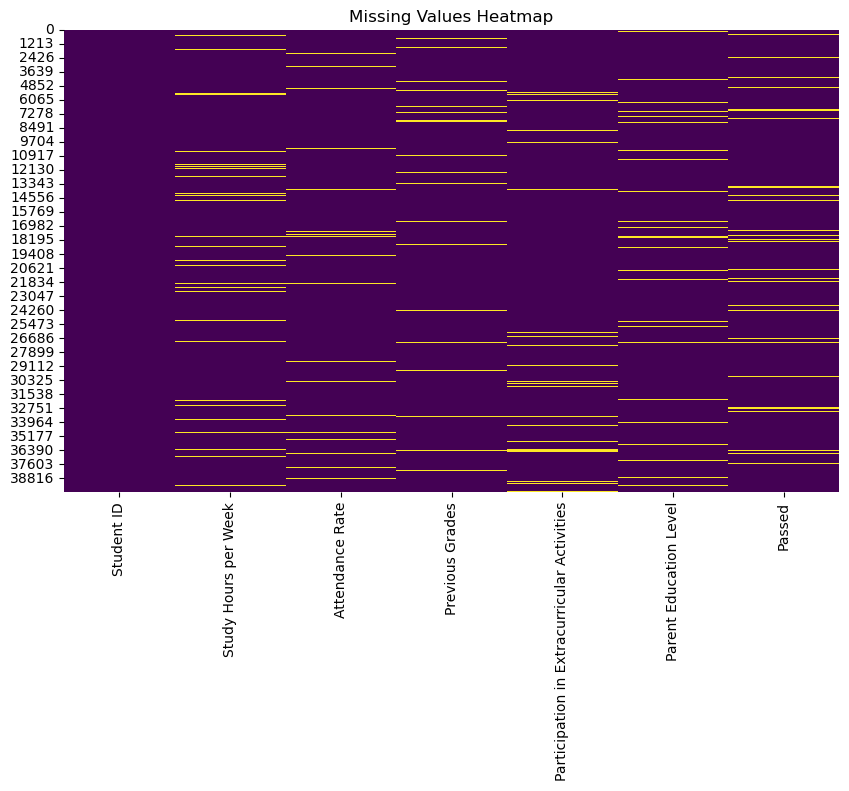

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [16]:
print("Negative Study Hours:", (df['Study Hours per Week'] < 0).sum())
print("Negative Attendance Rate:", (df['Attendance Rate'] < 0).sum())
print("Attendance Rate > 100:", (df['Attendance Rate'] > 100).sum())
print("Previous Grades > 100:", (df['Previous Grades'] > 100).sum())

Negative Study Hours: 941
Negative Attendance Rate: 5
Attendance Rate > 100: 4137
Previous Grades > 100: 481


In [17]:
df['Study Hours per Week'] = df['Study Hours per Week'].clip(lower=0)
df['Attendance Rate'] = df['Attendance Rate'].clip(lower=0, upper=100)
df['Previous Grades'] = df['Previous Grades'].clip(lower=0, upper=100)

In [18]:
print("Negative Study Hours:", (df['Study Hours per Week'] < 0).sum())
print("Negative Attendance Rate:", (df['Attendance Rate'] < 0).sum())
print("Attendance Rate > 100:", (df['Attendance Rate'] > 100).sum())
print("Previous Grades > 100:", (df['Previous Grades'] > 100).sum())

Negative Study Hours: 0
Negative Attendance Rate: 0
Attendance Rate > 100: 0
Previous Grades > 100: 0


In [19]:
df['Study Hours per Week'] = df['Study Hours per Week'].fillna(df['Study Hours per Week'].median())
df['Attendance Rate'] = df['Attendance Rate'].fillna(df['Attendance Rate'].median())
df['Previous Grades'] = df['Previous Grades'].fillna(df['Previous Grades'].median())

In [20]:
df['Participation in Extracurricular Activities'] = df['Participation in Extracurricular Activities'].fillna(df['Participation in Extracurricular Activities'].mode()[0])
df['Parent Education Level'] = df['Parent Education Level'].fillna(df['Parent Education Level'].mode()[0])

In [21]:
df = df.dropna(subset=['Passed'])

In [22]:
df.isna().sum()

Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

In [23]:
df.shape

(38000, 7)

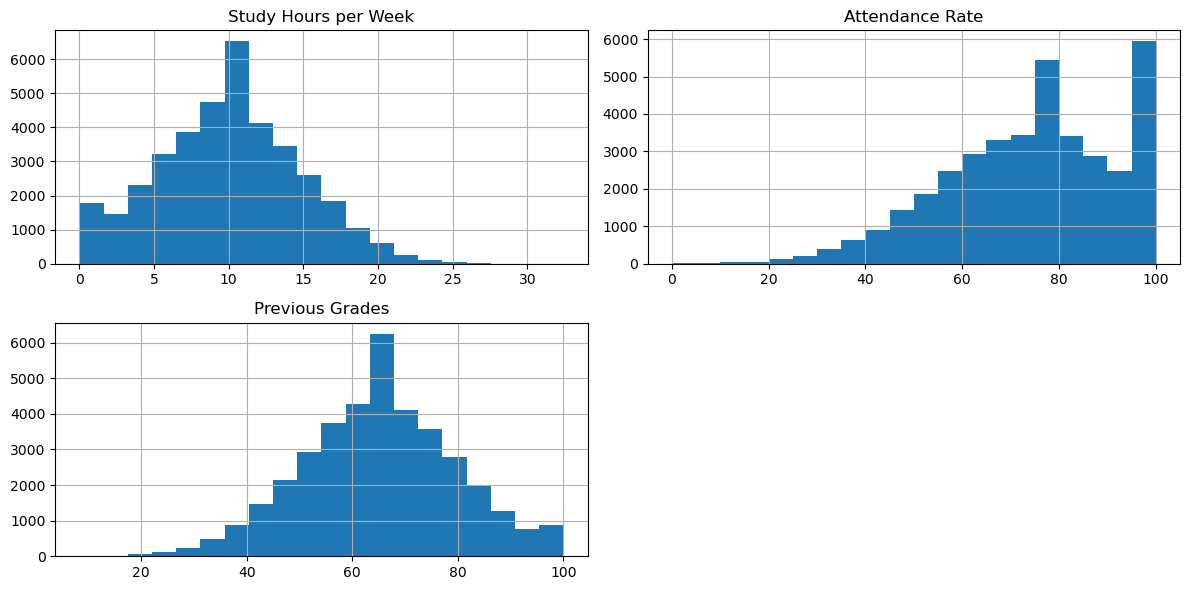

In [24]:
df[['Study Hours per Week', 'Attendance Rate', 'Previous Grades']].hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()

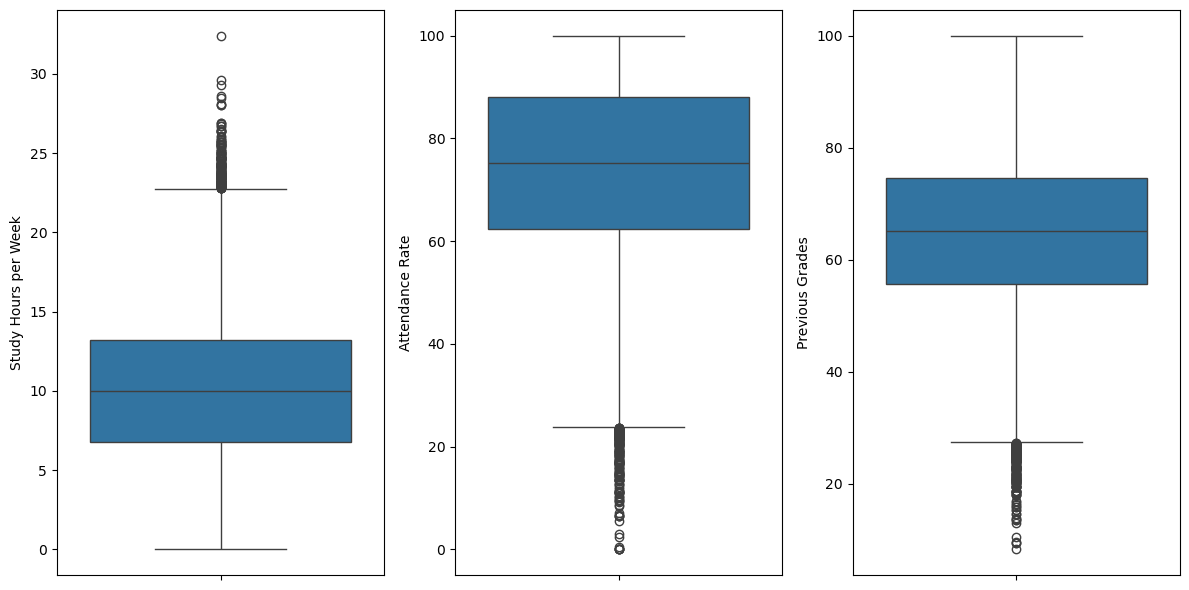

In [25]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Study Hours per Week'])
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Attendance Rate'])
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Previous Grades'])
plt.tight_layout()
plt.show()

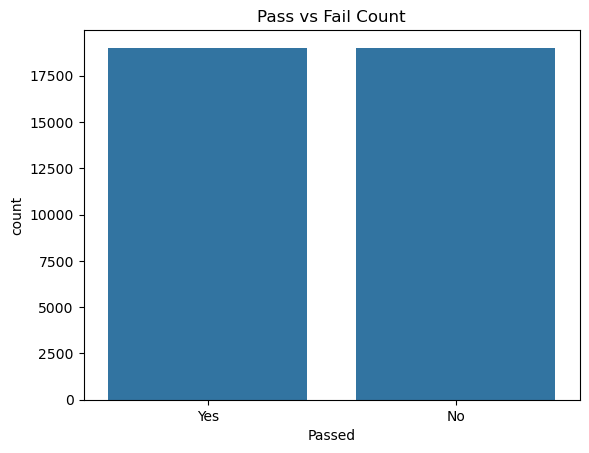

In [26]:
sns.countplot(x='Passed', data=df)
plt.title("Pass vs Fail Count")
plt.show()

In [27]:
df.groupby('Passed')[['Study Hours per Week', 'Attendance Rate', 'Previous Grades']].mean()

,Study Hours per Week,Attendance Rate,Previous Grades
Passed,,,
No,10.058781,74.014224,65.107546
Yes,9.961633,74.327190,65.151212


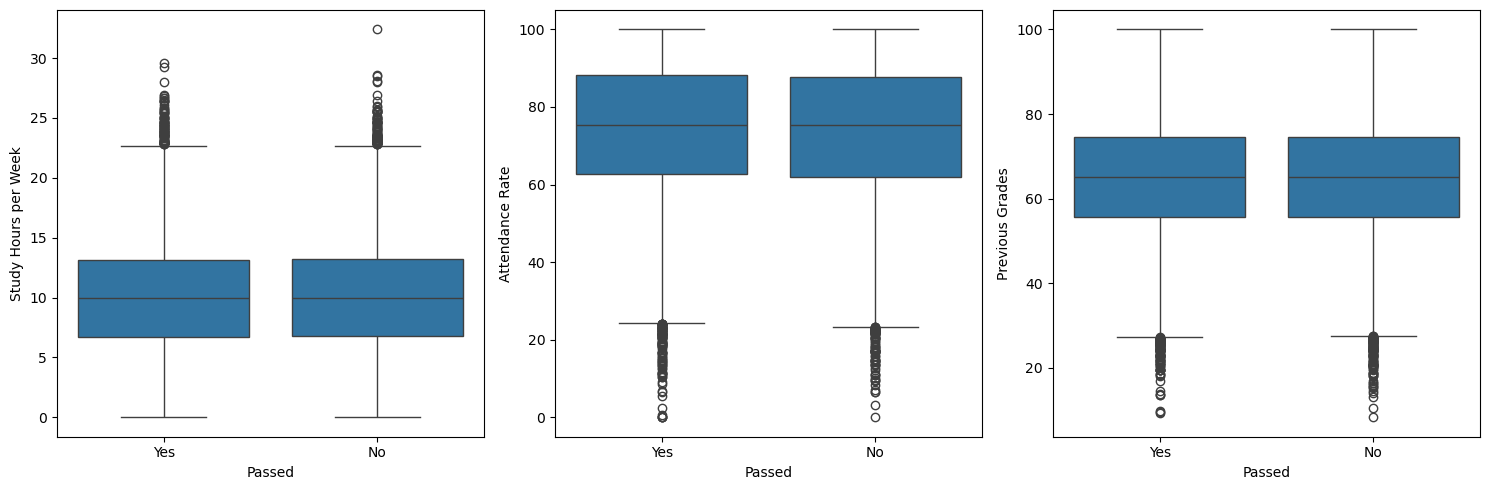

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Passed', y='Study Hours per Week', data=df, ax=axes[0])
sns.boxplot(x='Passed', y='Attendance Rate', data=df, ax=axes[1])
sns.boxplot(x='Passed', y='Previous Grades', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

In [29]:
df.groupby('Parent Education Level')['Passed'].value_counts(normalize=True).unstack()

Passed,No,Yes
Parent Education Level,,
Associate,0.507665,0.492335
Bachelor,0.497932,0.502068
Doctorate,0.492000,0.508000
High School,0.498486,0.501514
Master,0.503047,0.496953


In [30]:
df.groupby('Participation in Extracurricular Activities')['Passed'].value_counts(normalize=True).unstack()

Passed,No,Yes
Participation in Extracurricular Activities,,
No,0.499800,0.500200
Yes,0.499612,0.500388


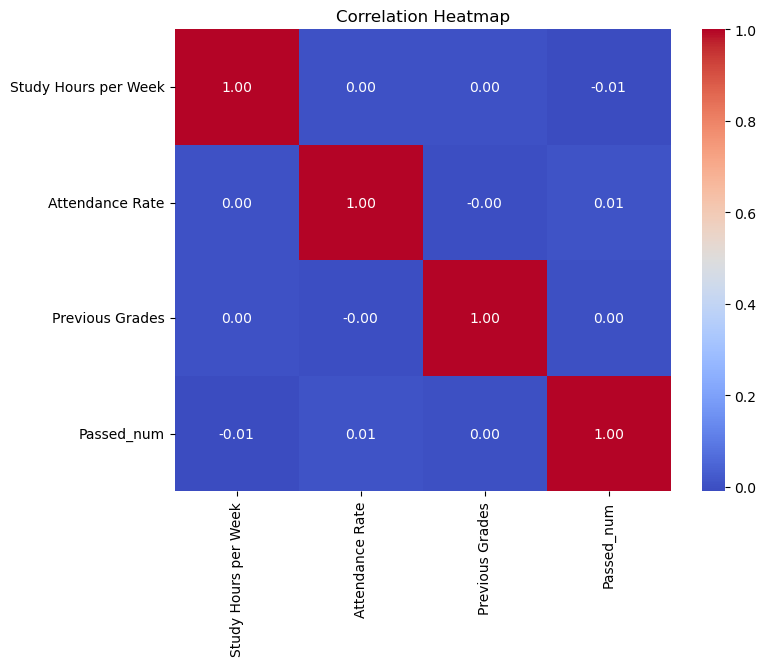

In [31]:
df_corr = df.copy()
df_corr['Passed_num'] = df_corr['Passed'].map({'Yes': 1, 'No': 0})
corr = df_corr[['Study Hours per Week', 'Attendance Rate', 'Previous Grades', 'Passed_num']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [32]:
df['Passed'] = df['Passed'].map({'Yes': 1, 'No': 0})

In [33]:
df['Participation in Extracurricular Activities'] = df['Participation in Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [34]:
df = pd.get_dummies(df, columns=['Parent Education Level'], drop_first=True)

In [35]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Passed,Parent Education Level_Bachelor,Parent Education Level_Doctorate,Parent Education Level_High School,Parent Education Level_Master
0,S00001,12.5,75.3,75.0,1,1,False,False,False,True
1,S00002,9.3,95.3,60.6,0,0,False,False,True,False
2,S00003,13.2,75.3,64.0,0,0,False,False,False,False
3,S00004,17.6,76.8,62.4,1,0,True,False,False,False
4,S00005,8.8,89.3,72.7,0,0,False,False,False,True


In [36]:
df = df.drop(columns=['Student ID'])

In [37]:
X = df.drop(columns=['Passed'])
y = df['Passed']

In [38]:
print(X.shape)
print(y.shape)
print(X.columns)

(38000, 8)
(38000,)
Index(['Study Hours per Week', 'Attendance Rate', 'Previous Grades',
       'Participation in Extracurricular Activities',
       'Parent Education Level_Bachelor', 'Parent Education Level_Doctorate',
       'Parent Education Level_High School', 'Parent Education Level_Master'],
      dtype='object')


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(30400, 8) (7600, 8)


In [40]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_pred_lr = model_lr.predict(X_test)
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", acc_lr)
print("Decision Tree Accuracy:", acc_dt)
print("Random Forest Accuracy:", acc_rf)

Logistic Regression Accuracy: 0.5002631578947369
Decision Tree Accuracy: 0.4986842105263158
Random Forest Accuracy: 0.5025


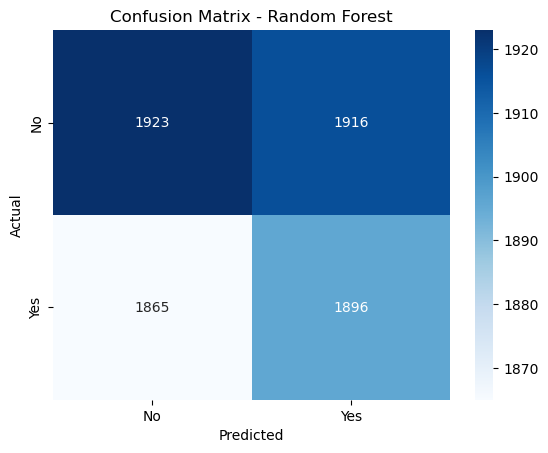

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.51      0.50      0.50      3839
           1       0.50      0.50      0.50      3761

    accuracy                           0.50      7600
   macro avg       0.50      0.50      0.50      7600
weighted avg       0.50      0.50      0.50      7600



In [48]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.500263
1        Decision Tree  0.498684
2        Random Forest  0.502500


## Final Summary

**Project**: Student Performance Prediction

**Data Cleaning**: 
- Identified and fixed invalid values (negative study hours, attendance rates outside 0-100%, grades above 100)
- Handled missing values: median imputation for numeric columns, mode imputation for categorical columns
- Dropped 2,000 rows with missing target variable, retaining 38,000 clean records

**EDA Findings**:
- Dataset is balanced (~50% Pass, ~50% Fail)
- No significant difference in average study hours, attendance rate, or previous grades between students who passed and those who didn't
- Correlation analysis showed near-zero correlation (-0.01 to 0.01) between all numeric features and the target
- Pass rates were nearly identical (~50%) across all categories of Parent Education Level and Extracurricular Activities

**Modeling**:
- Built and compared three classification models: Logistic Regression, Decision Tree, and Random Forest
- All models achieved ~50% accuracy, consistent with random guessing on a balanced binary target

**Conclusion**:
The EDA correctly predicted that no model would achieve meaningful predictive performance, since none of the available features showed any relationship with the target variable. This highlights the importance of conducting thorough exploratory data analysis before model building — it can reveal whether a dataset has any predictive signal, saving time and setting realistic expectations.